# Media Framing LLM Showcase

This notebook is designed for a lecturer-facing walkthrough of the final synchronous media-framing classification run.

It does four things:
- loads the final LLM classification output
- gives a compact overview of category patterns and source differences
- selects a small set of representative examples for each category
- adds English translations for presentation use while keeping the German original visible

The translation step is intentionally limited to the curated showcase sample and cached locally.


In [1]:
from pathlib import Path
import hashlib
import html
import json
import re
import sys

import pandas as pd
import matplotlib.pyplot as plt
import requests

from IPython.display import HTML, Markdown, display


try:
    import jinja2  # noqa: F401
    HAS_JINJA2 = True
except ImportError:
    HAS_JINJA2 = False

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    pass

pd.set_option('display.max_colwidth', 220)

PROJECT_ROOT = Path('/Users/MattisHaumann/Dev/Thesis')
RESULTS_PATH = PROJECT_ROOT / '2a_NER/outputs/batch_media_framing/thesis_final/normal_api_run/media_framing_thesis_sync_results.csv'
SHOWCASE_DIR = PROJECT_ROOT / '2a_NER/outputs/batch_media_framing/thesis_final/showcase'
SHOWCASE_DIR.mkdir(parents=True, exist_ok=True)

TRANSLATION_CACHE_PATH = SHOWCASE_DIR / 'media_framing_lecturer_translation_cache.csv'
SHOWCASE_EXPORT_PATH = SHOWCASE_DIR / 'media_framing_lecturer_examples.csv'

EXAMPLES_PER_CATEGORY = 3
RUN_TRANSLATIONS = True
TRANSLATION_MODEL = 'gpt-5-mini'
TRANSLATION_TIMEOUT = 180

CATEGORY_ORDER = [
    'POSITIONS-/PARTEILICHKEITS-BIAS',
    'VERZERRUNG/MANIPULATION',
    'DISINFORMATION/FALSCHDARSTELLUNG',
    'VERSAGEN/INKOMPETENZ',
    'NEUTRAL',
    'IRRELEVANT',
]

CATEGORY_ENGLISH = {
    'POSITIONS-/PARTEILICHKEITS-BIAS': 'Positional / Partisan Bias',
    'VERZERRUNG/MANIPULATION': 'Distortion / Manipulation',
    'DISINFORMATION/FALSCHDARSTELLUNG': 'Disinformation / Falsehood',
    'VERSAGEN/INKOMPETENZ': 'Failure / Incompetence',
    'NEUTRAL': 'Neutral',
    'IRRELEVANT': 'Irrelevant',
}

CATEGORY_DESCRIPTIONS_EN = {
    'POSITIONS-/PARTEILICHKEITS-BIAS': 'The outlet is framed as politically aligned, loyal to an ideology, or serving particular interests.',
    'VERZERRUNG/MANIPULATION': 'The outlet is accused of selective framing, omission, contextual distortion, or manipulative presentation.',
    'DISINFORMATION/FALSCHDARSTELLUNG': 'The outlet is accused of lying, spreading fake news, or publishing false claims as facts.',
    'VERSAGEN/INKOMPETENZ': 'The outlet is criticized as shallow, professionally weak, or failing at basic journalistic work.',
    'NEUTRAL': 'The media actor is merely named, cited, or referenced without evaluative framing.',
    'IRRELEVANT': 'The regex hit does not actually function as a media reference in context.',
}

SOURCE_LABELS = {
    'RT_de': 'RT',
    'Tichys_Einblick': 'Tichys Einblick',
}

assert RESULTS_PATH.exists(), f'Results file not found: {RESULTS_PATH}'
print(f'Results path: {RESULTS_PATH}')
print(f'Showcase output dir: {SHOWCASE_DIR}')


Results path: /Users/MattisHaumann/Dev/Thesis/2a_NER/outputs/batch_media_framing/thesis_final/normal_api_run/media_framing_thesis_sync_results.csv
Showcase output dir: /Users/MattisHaumann/Dev/Thesis/2a_NER/outputs/batch_media_framing/thesis_final/showcase


In [2]:
def normalize_source_label(value: object) -> str:
    if pd.isna(value):
        return ''
    value = str(value).strip()
    return SOURCE_LABELS.get(value, value)


def normalize_whitespace(text: object) -> str:
    if pd.isna(text):
        return ''
    return re.sub(r'\s+', ' ', str(text)).strip()


def build_context_excerpt(context: str, evidence: str, radius: int = 260, fallback: int = 420) -> str:
    context = normalize_whitespace(context)
    evidence = normalize_whitespace(evidence)
    if not context:
        return ''

    if evidence:
        match = re.search(re.escape(evidence), context, flags=re.IGNORECASE)
        if match:
            start = max(0, match.start() - radius)
            end = min(len(context), match.end() + radius)
            excerpt = context[start:end].strip()
            if start > 0:
                excerpt = '… ' + excerpt
            if end < len(context):
                excerpt = excerpt + ' …'
            return excerpt

    if len(context) <= fallback:
        return context
    return context[:fallback].rsplit(' ', 1)[0].strip() + ' …'


results_df = pd.read_csv(RESULTS_PATH)
results_df['source_label'] = results_df['source'].map(normalize_source_label)
results_df['title_de'] = results_df['Title'].map(normalize_whitespace)
results_df['hit_text'] = results_df['hit_text'].map(normalize_whitespace)
results_df['evidence_de'] = results_df['evidence'].map(normalize_whitespace)
results_df['context_window'] = results_df['context_window'].map(normalize_whitespace)
results_df['category'] = pd.Categorical(results_df['category'], categories=CATEGORY_ORDER, ordered=True)
results_df['category_en'] = results_df['category'].map(CATEGORY_ENGLISH)
results_df['evidence_present'] = results_df['evidence_de'].ne('')
results_df['context_excerpt_de'] = results_df.apply(
    lambda row: build_context_excerpt(row['context_window'], row['evidence_de']),
    axis=1,
)
results_df['title_key'] = results_df['title_de'].str.lower()
results_df['excerpt_len'] = results_df['context_excerpt_de'].str.len()
results_df['evidence_len'] = results_df['evidence_de'].str.len()
results_df['is_bias_label'] = ~results_df['category'].isin(['NEUTRAL', 'IRRELEVANT'])

overview = pd.Series(
    {
        'classified hits': len(results_df),
        'unique row_id values': results_df['row_id'].nunique(),
        'unique sources': results_df['source_label'].nunique(),
        'unique categories': results_df['category'].nunique(),
        'rows with explicit evidence spans': int(results_df['evidence_present'].sum()),
    }
)

display(overview.to_frame('value'))
display(
    results_df[
        ['source_label', 'title_de', 'hit_text', 'category', 'evidence_de', 'context_excerpt_de']
    ].head(5)
)


,value
classified hits,11973
unique row_id values,7204
unique sources,7
unique categories,6
rows with explicit evidence spans,3192


,source_label,title_de,hit_text,category,evidence_de,context_excerpt_de
0,Antispiegel,Bereitet der Westen die Entmachtung oder sogar den Sturz Selenskys vor?,Politico,NEUTRAL,,"Er hat es geschafft, seine Leute überall zu platzieren und selbst braucht nichts er außer Sicherheitsgarantien und Geld. Darüber hinaus haben die Amerikaner, wie Politico im März schrieb, in der Opposition bereits ei..."
1,Antispiegel,Fordert Russland wirklich die Vernichtung aller Ukrainer?,Bild-Zeitung,DISINFORMATION/FALSCHDARSTELLUNG,Propagandisten von Bild-Zeitung,Viele haben Reitschuster aus der Corona-Zeit ja als guten Journalisten in Erinnerung. Aber beim Thema Russland betreibt er Desinformation seiner Leser und belügt sie nicht weniger dreist als die Propagandisten von Bi...
2,Antispiegel,Der Spiegel macht mal wieder Berichterstattung für den Kindergarten,Spiegel,VERSAGEN/INKOMPETENZ,Berichterstattung für den Kindergarten,"Der Spiegel macht mal wieder Berichterstattung für den Kindergarten. Wer auch nicht-westliche Medien liest, der ist öfters wahlweise schockiert oder belustigt darüber, wie unterschiedlich deutsche und nicht-westliche..."
3,Antispiegel,Der Spiegel macht mal wieder Berichterstattung für den Kindergarten,Spiegel,NEUTRAL,,"Das NABU ist das vielleicht wichtigste Instrument des Westens zur Kontrolle der Ukraine und ihrer Regierung. Für Stammleser des Anti-Spiegel ist das nichts Neues, weil ich darüber seit Jahren berichte und es auch in ..."
4,Antispiegel,Der Spiegel macht mal wieder Berichterstattung für den Kindergarten,Spiegel,POSITIONS-/PARTEILICHKEITS-BIAS,anti-russischen und pro-ukrainischen Propagandisten,"… nke, die Antwort liegt auf der Hand. Märchenstunde im Spiegel Daher ist es niedlich, wie der Spiegel seinen Lesern nun, nachdem Selensky eingeknickt ist und das Gesetz wieder zurückgenommen hat, seinen Lesern Märch..."


## Clean Overview

The two views below are the ones most useful in class:
- how often each category appears overall
- how category mixes differ by outlet


,category_en,category,hits,share_of_hits,unique_articles,outlets,evidence_spans,evidence_share_within_category
0,Positional / Partisan Bias,POSITIONS-/PARTEILICHKEITS-BIAS,1409,11.8%,964,7,1409,100.0%
1,Distortion / Manipulation,POSITIONS-/PARTEILICHKEITS-BIAS,0,0.0%,0,0,0,nan%
2,Disinformation / Falsehood,POSITIONS-/PARTEILICHKEITS-BIAS,0,0.0%,0,0,0,nan%
3,Failure / Incompetence,POSITIONS-/PARTEILICHKEITS-BIAS,0,0.0%,0,0,0,nan%
4,Neutral,POSITIONS-/PARTEILICHKEITS-BIAS,0,0.0%,0,0,0,nan%
5,Irrelevant,POSITIONS-/PARTEILICHKEITS-BIAS,0,0.0%,0,0,0,nan%
6,Positional / Partisan Bias,VERZERRUNG/MANIPULATION,0,0.0%,0,0,0,nan%
7,Distortion / Manipulation,VERZERRUNG/MANIPULATION,1084,9.1%,764,7,1084,100.0%
8,Disinformation / Falsehood,VERZERRUNG/MANIPULATION,0,0.0%,0,0,0,nan%
9,Failure / Incompetence,VERZERRUNG/MANIPULATION,0,0.0%,0,0,0,nan%


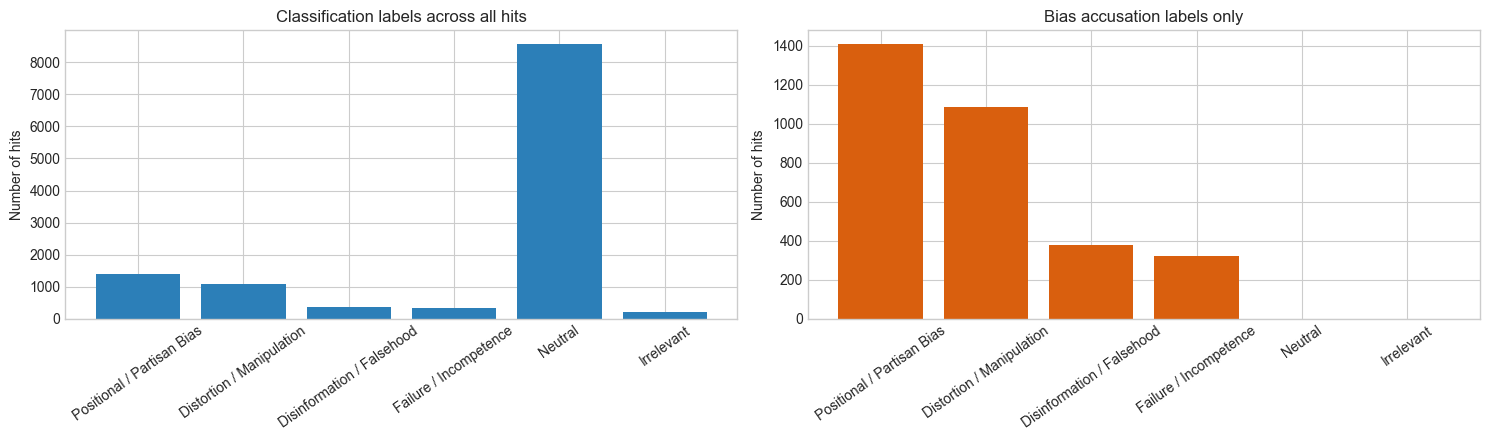

category_en,Positional / Partisan Bias,Distortion / Manipulation,Disinformation / Falsehood,Failure / Incompetence,Neutral,Irrelevant
source_label,,,,,,
Antispiegel,13.9%,30.2%,8.3%,4.8%,41.3%,1.5%
Compact,15.8%,11.3%,6.6%,1.8%,55.3%,9.2%
Deutschlandkurier,24.7%,5.5%,4.7%,1.3%,63.5%,0.3%
Nius,17.9%,14.6%,5.3%,4.5%,55.6%,2.1%
RT,9.2%,8.6%,2.3%,1.2%,77.0%,1.7%
Tagesschau,0.7%,0.3%,0.1%,0.1%,98.0%,0.8%
Tichys Einblick,26.0%,16.3%,5.4%,7.1%,42.9%,2.1%


In [3]:
category_summary = (
    results_df.groupby(['category', 'category_en'], observed=False)
    .agg(
        hits=('hit_id', 'size'),
        unique_articles=('row_id', 'nunique'),
        outlets=('source_label', 'nunique'),
        evidence_spans=('evidence_present', 'sum'),
    )
    .reset_index()
)
category_summary['share_of_hits'] = category_summary['hits'] / len(results_df)
category_summary['evidence_share_within_category'] = (
    category_summary['evidence_spans'] / category_summary['hits']
)

overview_table = category_summary[
    [
        'category_en',
        'category',
        'hits',
        'share_of_hits',
        'unique_articles',
        'outlets',
        'evidence_spans',
        'evidence_share_within_category',
    ]
].copy()

if HAS_JINJA2:
    display(
        overview_table.style.format(
            {
                'share_of_hits': '{:.1%}',
                'evidence_share_within_category': '{:.1%}',
            }
        )
    )
else:
    display(overview_table)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

plot_summary = category_summary.copy()
axes[0].bar(plot_summary['category_en'], plot_summary['hits'], color='#2c7fb8')
axes[0].set_title('Classification labels across all hits')
axes[0].set_ylabel('Number of hits')
axes[0].tick_params(axis='x', rotation=35)

bias_only = plot_summary[~plot_summary['category'].isin(['NEUTRAL', 'IRRELEVANT'])].copy()
axes[1].bar(bias_only['category_en'], bias_only['hits'], color='#d95f0e')
axes[1].set_title('Bias accusation labels only')
axes[1].set_ylabel('Number of hits')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

source_category_share = pd.crosstab(
    results_df['source_label'],
    results_df['category_en'],
    normalize='index',
).reindex(columns=[CATEGORY_ENGLISH[c] for c in CATEGORY_ORDER])

if HAS_JINJA2:
    display(
        source_category_share.style.format('{:.1%}').background_gradient(cmap='Blues')
        .set_caption('Within-outlet category mix')
    )
else:
    display(source_category_share)


## Category Glossary

This compact English glossary is useful when explaining the annotation scheme to a lecturer who has not seen the German prompt taxonomy.


In [4]:
codebook_df = pd.DataFrame(
    [
        {
            'Category (DE)': category,
            'Category (EN)': CATEGORY_ENGLISH[category],
            'How to explain it in class': CATEGORY_DESCRIPTIONS_EN[category],
        }
        for category in CATEGORY_ORDER
    ]
)

display(codebook_df)


,Category (DE),Category (EN),How to explain it in class
0,POSITIONS-/PARTEILICHKEITS-BIAS,Positional / Partisan Bias,"The outlet is framed as politically aligned, loyal to an ideology, or serving particular interests."
1,VERZERRUNG/MANIPULATION,Distortion / Manipulation,"The outlet is accused of selective framing, omission, contextual distortion, or manipulative presentation."
2,DISINFORMATION/FALSCHDARSTELLUNG,Disinformation / Falsehood,"The outlet is accused of lying, spreading fake news, or publishing false claims as facts."
3,VERSAGEN/INKOMPETENZ,Failure / Incompetence,"The outlet is criticized as shallow, professionally weak, or failing at basic journalistic work."
4,NEUTRAL,Neutral,"The media actor is merely named, cited, or referenced without evaluative framing."
5,IRRELEVANT,Irrelevant,The regex hit does not actually function as a media reference in context.


## Curated Showcase Sample

The goal here is not to inspect all rows, but to pick representative examples that are easy to explain aloud.

Selection logic:
- prefer rows with clear evidence spans for accusation labels
- keep excerpts short enough for presentation
- avoid repeating the same article when possible
- try to keep some source diversity inside each category


In [5]:
def example_score(row: pd.Series) -> float:
    context_score = max(0.0, 1 - abs(row['excerpt_len'] - 380) / 380)
    title_bonus = 0.15 if row['title_de'] else 0.0
    mention_bonus = 0.15 if row['hit_text'] else 0.0

    if row['category'] in ['NEUTRAL', 'IRRELEVANT']:
        return context_score + title_bonus + mention_bonus

    evidence_score = 2.0 if row['evidence_present'] else -3.0
    evidence_score += max(0.0, 1 - abs(row['evidence_len'] - 45) / 45)
    return context_score + evidence_score + title_bonus + mention_bonus


results_df['showcase_score'] = results_df.apply(example_score, axis=1)


def select_examples_for_category(group: pd.DataFrame, n: int) -> pd.DataFrame:
    ranked = group.sort_values(
        ['showcase_score', 'evidence_len', 'excerpt_len'],
        ascending=False,
    ).copy()

    selected_indices = []
    used_titles = set()
    used_sources = set()
    source_diversity_available = ranked['source_label'].nunique() >= n

    for _, row in ranked.iterrows():
        if len(selected_indices) >= n:
            break
        if row['title_key'] in used_titles:
            continue
        if source_diversity_available and row['source_label'] in used_sources:
            continue

        selected_indices.append(row.name)
        used_titles.add(row['title_key'])
        used_sources.add(row['source_label'])

    if len(selected_indices) < n:
        for _, row in ranked.iterrows():
            if len(selected_indices) >= n:
                break
            if row.name in selected_indices:
                continue
            if row['title_key'] in used_titles:
                continue

            selected_indices.append(row.name)
            used_titles.add(row['title_key'])

    return ranked.loc[selected_indices].head(n)


showcase_examples = pd.concat(
    [
        select_examples_for_category(
            results_df[results_df['category'] == category].copy(),
            EXAMPLES_PER_CATEGORY,
        )
        for category in CATEGORY_ORDER
    ],
    ignore_index=True,
)

showcase_examples['example_rank'] = showcase_examples.groupby('category', observed=False).cumcount() + 1
showcase_examples['translation_key'] = showcase_examples.apply(
    lambda row: hashlib.md5(
        '||'.join(
            [
                row['category'],
                row['title_de'],
                row['evidence_de'],
                row['context_excerpt_de'],
            ]
        ).encode('utf-8')
    ).hexdigest(),
    axis=1,
)

display(
    showcase_examples[
        [
            'category_en',
            'example_rank',
            'source_label',
            'title_de',
            'hit_text',
            'evidence_de',
            'showcase_score',
        ]
    ]
)

showcase_examples.to_csv(SHOWCASE_EXPORT_PATH, index=False, encoding='utf-8')
print(f'Showcase sample saved to: {SHOWCASE_EXPORT_PATH}')


,category_en,example_rank,source_label,title_de,hit_text,evidence_de,showcase_score
0,Positional / Partisan Bias,1,Tichys Einblick,Wie man beim MDR ganz offiziell auf die Staatsferne pfeift,MDR,"Aufwandsentschädigung in Höhe von 834,23 Euro",4.292105
1,Positional / Partisan Bias,2,Antispiegel,Was der Spiegel über die Festnahmen wegen Korruption in Brüssel verschweigt,Spiegel,über die der Spiegel kritisch berichten würde,4.284211
2,Positional / Partisan Bias,3,Nius,Das Protokoll des Angriffs auf Julia Ruhs,NDR | Politico | ÖRR,Unterwanderung durch Rechte und Neofaschisten,4.252632
3,Distortion / Manipulation,1,Antispiegel,Wenn der Spiegel über Proteste in Russland berichtet,Qualitätsmedien,teilen ihren deutschen Lesern nicht einmal mit,4.275146
4,Distortion / Manipulation,2,Tichys Einblick,Mit durchgedrücktem Rücken der Gemeinschaft dienen,Deutschlandfunk,entdeckte bereits 2020 „rassistische Muster“,4.269883
5,Distortion / Manipulation,3,Tagesschau,"Ein ""Scheinkonflikt"" - oder doch mehr?",Bild,zu einem scheinbar großen Konflikt gemacht hat,4.256725
6,Disinformation / Falsehood,1,Nius,Krise bei Volkswagen! Golf-Produktion wird gestoppt +++ Werk Zwickau in Kurzarbeit?,Bild | NDR | Bild-Zeitung,Die Darstellung der Bild-Zeitung sei falsch.,4.272515
7,Disinformation / Falsehood,2,Tichys Einblick,Gelingt der Sturz der Mullahs im Iran? – Massive EU-Bauernproteste,Gesternmedien,Verschweigen und Fälschen der Wahrheit,4.133918
8,Disinformation / Falsehood,3,Antispiegel,Mit welchen Märchen der Spiegel die Kriegshysterie in Deutschland schürt,Spiegel,diese Lügen als Tatsachen darzustellen und zu verbreiten,4.045029
9,Failure / Incompetence,1,Nius,Die Restle-Rampe über „AfD und radikale Christen“: Wie ein „Monitor“-Beitrag den Journalismus blamiert,Correctiv,desaströs gescheiterten Correctiv-Geschichte,4.272515


Showcase sample saved to: /Users/MattisHaumann/Dev/Thesis/2a_NER/outputs/batch_media_framing/thesis_final/showcase/media_framing_lecturer_examples.csv


## English Translations For The Lecturer Version

This cell translates only the curated examples, not the full dataset. The result is cached to CSV, so reruns should usually be free after the first successful pass.


In [6]:
HELPER_DIR = PROJECT_ROOT / '2a_NER'
if str(HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(HELPER_DIR))

from media_framing_batch_utils import extract_output_text_from_responses_body, read_env_value

TRANSLATION_SCHEMA = {
    'type': 'object',
    'additionalProperties': False,
    'properties': {
        'title_en': {'type': 'string'},
        'evidence_en': {'type': 'string'},
        'excerpt_en': {'type': 'string'},
    },
    'required': ['title_en', 'evidence_en', 'excerpt_en'],
}

TRANSLATION_INSTRUCTIONS = (
    'Translate the provided German media-framing example into fluent English for an academic presentation. '
    'Preserve the accusation strength, framing, and tone. '
    'Do not summarize or soften the wording. '
    'Translate the evidence as a short, telling English phrase. '
    'If the evidence field is empty, return an empty string for evidence_en. '
    'Return valid JSON only.'
)


def load_translation_cache(path: Path) -> pd.DataFrame:
    if path.exists() and path.stat().st_size > 0:
        return pd.read_csv(path)
    return pd.DataFrame(
        columns=['translation_key', 'title_en', 'evidence_en', 'excerpt_en']
    )


def save_translation_cache(cache_df: pd.DataFrame, path: Path) -> None:
    if cache_df.empty:
        return
    cache_df = cache_df.drop_duplicates(subset=['translation_key'], keep='last').copy()
    cache_df.to_csv(path, index=False, encoding='utf-8')


def request_translation(session: requests.Session, row: pd.Series) -> dict:
    payload = {
        'model': TRANSLATION_MODEL,
        'instructions': TRANSLATION_INSTRUCTIONS,
        'input': (
            f"Title (German):\n{row['title_de']}\n\n"
            f"Evidence span (German):\n{row['evidence_de']}\n\n"
            f"Excerpt (German):\n{row['context_excerpt_de']}"
        ),
        'text': {
            'format': {
                'type': 'json_schema',
                'name': 'showcase_translation',
                'strict': True,
                'schema': TRANSLATION_SCHEMA,
            }
        },
    }

    response = session.post(
        'https://api.openai.com/v1/responses',
        json=payload,
        timeout=TRANSLATION_TIMEOUT,
    )
    response.raise_for_status()
    response_json = response.json()
    return json.loads(extract_output_text_from_responses_body(response_json))


translation_cache = load_translation_cache(TRANSLATION_CACHE_PATH)
cache_lookup = (
    translation_cache.drop_duplicates(subset=['translation_key'], keep='last')
    .set_index('translation_key')
    .to_dict('index')
    if not translation_cache.empty
    else {}
)

api_key, api_key_source = read_env_value('OPENAI_API_KEY', project_root=PROJECT_ROOT)
print(f'Cached translations already available: {len(cache_lookup):,}')
print(f'OPENAI_API_KEY source: {api_key_source}')

session = None
if RUN_TRANSLATIONS and api_key:
    session = requests.Session()
    session.headers.update(
        {
            'Authorization': f'Bearer {api_key}',
            'Content-Type': 'application/json',
        }
    )
elif RUN_TRANSLATIONS:
    print('OPENAI_API_KEY not found. Translation step will use cache only.')
else:
    print('RUN_TRANSLATIONS = False. Translation step will use cache only.')

translated_rows = []
translation_errors = []

for _, row in showcase_examples.iterrows():
    key = row['translation_key']

    if key in cache_lookup:
        translated_rows.append({'translation_key': key, **cache_lookup[key]})
        continue

    if session is None:
        translated_rows.append(
            {
                'translation_key': key,
                'title_en': '',
                'evidence_en': '',
                'excerpt_en': '',
            }
        )
        continue

    try:
        translated = request_translation(session, row)
        record = {
            'translation_key': key,
            'title_en': translated.get('title_en', '').strip(),
            'evidence_en': translated.get('evidence_en', '').strip(),
            'excerpt_en': translated.get('excerpt_en', '').strip(),
        }
        translated_rows.append(record)
        cache_lookup[key] = record
        translation_cache = pd.concat([translation_cache, pd.DataFrame([record])], ignore_index=True)
        save_translation_cache(translation_cache, TRANSLATION_CACHE_PATH)
    except Exception as exc:
        translation_errors.append(
            {
                'translation_key': key,
                'category': row['category'],
                'source_label': row['source_label'],
                'title_de': row['title_de'],
                'error': str(exc),
            }
        )
        translated_rows.append(
            {
                'translation_key': key,
                'title_en': '',
                'evidence_en': '',
                'excerpt_en': '',
            }
        )

translations_df = pd.DataFrame(translated_rows).drop_duplicates('translation_key', keep='last')
showcase_examples = showcase_examples.drop(
    columns=['title_en', 'evidence_en', 'excerpt_en'],
    errors='ignore',
).merge(translations_df, on='translation_key', how='left')

for column in ['title_en', 'evidence_en', 'excerpt_en']:
    showcase_examples[column] = showcase_examples[column].fillna('').astype(str)

showcase_examples.to_csv(SHOWCASE_EXPORT_PATH, index=False, encoding='utf-8')
print(f'Updated showcase export: {SHOWCASE_EXPORT_PATH}')
print(f'Translation cache: {TRANSLATION_CACHE_PATH}')

if translation_errors:
    display(pd.DataFrame(translation_errors))

display(
    showcase_examples[
        ['category_en', 'example_rank', 'source_label', 'title_en', 'evidence_en']
    ]
)


Cached translations already available: 0
OPENAI_API_KEY source: environment variable
Updated showcase export: /Users/MattisHaumann/Dev/Thesis/2a_NER/outputs/batch_media_framing/thesis_final/showcase/media_framing_lecturer_examples.csv
Translation cache: /Users/MattisHaumann/Dev/Thesis/2a_NER/outputs/batch_media_framing/thesis_final/showcase/media_framing_lecturer_translation_cache.csv


,category_en,example_rank,source_label,title_en,evidence_en
0,Positional / Partisan Bias,1,Tichys Einblick,How MDR Officially Flouts Its Supposed Distance from the State,Monthly expense allowance of €834.23
1,Positional / Partisan Bias,2,Antispiegel,What Der Spiegel Is Hiding About the Arrests Over Corruption in Brussels,about whom Der Spiegel would report critically
2,Positional / Partisan Bias,3,Nius,The Record of the Attack on Julia Ruhs,Infiltration by the Right and neo-fascists
3,Distortion / Manipulation,1,Antispiegel,When Der Spiegel Reports on Protests in Russia,do not even inform their German readers
4,Distortion / Manipulation,2,Tichys Einblick,Serving the Community with a Stooped Back,"discovered ""racist patterns"" in 2020"
5,Distortion / Manipulation,3,Tagesschau,"A ""sham conflict"" — or is it more?",has turned it into an apparently major conflict
6,Disinformation / Falsehood,1,Nius,Crisis at Volkswagen! Golf production stopped +++ Zwickau plant on short-time work?,The Bild newspaper's account is false.
7,Disinformation / Falsehood,2,Tichys Einblick,Will the Overthrow of the Mullahs in Iran Succeed? – Massive EU Farmer Protests,Concealing and falsifying the truth
8,Disinformation / Falsehood,3,Antispiegel,Which fairy tales Der Spiegel uses to stoke war hysteria in Germany,to portray and spread these lies as facts
9,Failure / Incompetence,1,Nius,The Restle Ramp about 'AfD and Radical Christians': How a 'Monitor' Segment Embarrasses Journalism,the disastrously failed Correctiv story


## Final Lecturer-Facing Render

Each card keeps the German original visible, but surfaces the English translation directly underneath it.

For the accusation labels, the German evidence span is highlighted in context. For `Neutral` and `Irrelevant`, no evidence span is expected.


In [7]:
CATEGORY_COLORS = {
    'POSITIONS-/PARTEILICHKEITS-BIAS': '#b2182b',
    'VERZERRUNG/MANIPULATION': '#ef8a62',
    'DISINFORMATION/FALSCHDARSTELLUNG': '#542788',
    'VERSAGEN/INKOMPETENZ': '#2166ac',
    'NEUTRAL': '#4d4d4d',
    'IRRELEVANT': '#7f7f7f',
}


def safe_text(value: object, placeholder: str = '—') -> str:
    value = '' if pd.isna(value) else str(value).strip()
    return value if value else placeholder


def highlight_evidence_html(text: str, evidence: str) -> str:
    text = normalize_whitespace(text)
    evidence = normalize_whitespace(evidence)
    if not text:
        return '—'
    if not evidence:
        return html.escape(text)

    match = re.search(re.escape(evidence), text, flags=re.IGNORECASE)
    if not match:
        return html.escape(text)

    return (
        html.escape(text[: match.start()])
        + '<mark>'
        + html.escape(text[match.start() : match.end()])
        + '</mark>'
        + html.escape(text[match.end() :])
    )


DISPLAY_CSS = '''
<style>
.showcase-grid {
    display: grid;
    grid-template-columns: 1fr;
    gap: 16px;
    margin: 12px 0 28px 0;
}
.showcase-card {
    border: 1px solid #d9d9d9;
    border-left: 8px solid var(--accent-color);
    border-radius: 10px;
    padding: 16px 18px;
    background: #ffffff;
    box-shadow: 0 1px 4px rgba(0, 0, 0, 0.04);
}
.showcase-meta {
    font-size: 12px;
    color: #555;
    margin-bottom: 10px;
    letter-spacing: 0.02em;
    text-transform: uppercase;
}
.showcase-title {
    font-size: 17px;
    font-weight: 700;
    margin-bottom: 10px;
}
.showcase-pair {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 16px;
    margin-top: 10px;
}
.showcase-box {
    background: #fafafa;
    border: 1px solid #ececec;
    border-radius: 8px;
    padding: 12px;
}
.showcase-label {
    font-size: 12px;
    font-weight: 700;
    color: #444;
    margin-bottom: 6px;
    text-transform: uppercase;
    letter-spacing: 0.03em;
}
.showcase-text {
    font-size: 14px;
    line-height: 1.55;
    color: #111;
}
.showcase-evidence {
    font-weight: 700;
    color: #111;
}
mark {
    background: #fff2a8;
    padding: 0 2px;
}
@media (max-width: 900px) {
    .showcase-pair {
        grid-template-columns: 1fr;
    }
}
</style>
'''

display(HTML(DISPLAY_CSS))


def render_example_card(row: pd.Series) -> str:
    accent = CATEGORY_COLORS.get(row['category'], '#999999')
    evidence_de = safe_text(
        row['evidence_de'],
        placeholder='No explicit evidence span (expected for Neutral / Irrelevant).',
    )
    evidence_en = safe_text(
        row['evidence_en'],
        placeholder='No explicit evidence span.' if row['category'] in ['NEUTRAL', 'IRRELEVANT'] else '[translation pending]',
    )
    title_en = safe_text(row['title_en'], placeholder='[translation pending]')
    excerpt_en = safe_text(row['excerpt_en'], placeholder='[translation pending]')
    mention = safe_text(row['hit_text'])
    excerpt_de_html = highlight_evidence_html(row['context_excerpt_de'], row['evidence_de'])

    return f'''
    <div class="showcase-card" style="--accent-color: {accent};">
        <div class="showcase-meta">Example {int(row['example_rank'])} | {html.escape(row['source_label'])} | matched media mention: {html.escape(mention)}</div>
        <div class="showcase-title">{html.escape(row['category_en'])}</div>
        <div class="showcase-pair">
            <div class="showcase-box">
                <div class="showcase-label">German title</div>
                <div class="showcase-text">{html.escape(safe_text(row['title_de']))}</div>
            </div>
            <div class="showcase-box">
                <div class="showcase-label">English title</div>
                <div class="showcase-text">{html.escape(title_en)}</div>
            </div>
        </div>
        <div class="showcase-pair">
            <div class="showcase-box">
                <div class="showcase-label">Evidence span in German</div>
                <div class="showcase-text showcase-evidence">{html.escape(evidence_de)}</div>
            </div>
            <div class="showcase-box">
                <div class="showcase-label">Evidence span in English</div>
                <div class="showcase-text showcase-evidence">{html.escape(evidence_en)}</div>
            </div>
        </div>
        <div class="showcase-pair">
            <div class="showcase-box">
                <div class="showcase-label">German excerpt</div>
                <div class="showcase-text">{excerpt_de_html}</div>
            </div>
            <div class="showcase-box">
                <div class="showcase-label">English excerpt</div>
                <div class="showcase-text">{html.escape(excerpt_en)}</div>
            </div>
        </div>
    </div>
    '''


for category in CATEGORY_ORDER:
    category_examples = showcase_examples[showcase_examples['category'] == category].copy()
    if category_examples.empty:
        continue

    display(Markdown(f"## {CATEGORY_ENGLISH[category]}"))
    display(
        Markdown(
            f"**German category label:** `{category}`  \n"
            f"{CATEGORY_DESCRIPTIONS_EN[category]}"
        )
    )
    cards_html = ''.join(render_example_card(row) for _, row in category_examples.iterrows())
    display(HTML(f'<div class="showcase-grid">{cards_html}</div>'))

print(f'Curated lecturer showcase exported to: {SHOWCASE_EXPORT_PATH}')


## Positional / Partisan Bias

**German category label:** `POSITIONS-/PARTEILICHKEITS-BIAS`  
The outlet is framed as politically aligned, loyal to an ideology, or serving particular interests.

## Distortion / Manipulation

**German category label:** `VERZERRUNG/MANIPULATION`  
The outlet is accused of selective framing, omission, contextual distortion, or manipulative presentation.

## Disinformation / Falsehood

...

## Neutral

**German category label:** `NEUTRAL`  
The media actor is merely named, cited, or referenced without evaluative framing.

## Irrelevant

**German category label:** `IRRELEVANT`  
The regex hit does not actually function as a media reference in context.

Curated lecturer showcase exported to: /Users/MattisHaumann/Dev/Thesis/2a_NER/outputs/batch_media_framing/thesis_final/showcase/media_framing_lecturer_examples.csv


In [8]:
from IPython.display import Markdown, display
import pandas as pd

SHORT_EXCERPT_CHARS = 260

def pick_text(*values):
    for value in values:
        if pd.notna(value) and str(value).strip():
            return str(value).strip()
    return ""

def shorten(text, limit=SHORT_EXCERPT_CHARS):
    text = pick_text(text)
    if len(text) <= limit:
        return text
    return text[:limit].rsplit(" ", 1)[0].strip() + " ..."

def quick_reason(row):
    span = pick_text(row.get("evidence_en"), row.get("evidence_de"))
    mention = pick_text(row.get("hit_text"), "the media reference")

    if row["category"] == "POSITIONS-/PARTEILICHKEITS-BIAS":
        return f'The key phrase is "{span}". It frames {mention} as politically or ideologically aligned.'
    if row["category"] == "VERZERRUNG/MANIPULATION":
        return f'The key phrase is "{span}". It suggests selective framing, omission, or distortion.'
    if row["category"] == "DISINFORMATION/FALSCHDARSTELLUNG":
        return f'The key phrase is "{span}". It accuses {mention} of falsehood or lying.'
    if row["category"] == "VERSAGEN/INKOMPETENZ":
        return f'The key phrase is "{span}". It presents the outlet as weak, sloppy, or journalistically poor.'
    if row["category"] == "NEUTRAL":
        return f"{mention} is just cited or referenced here, not attacked."
    if row["category"] == "IRRELEVANT":
        return f'"{mention}" is not functioning as a media reference in this context.'
    return ""

for category in CATEGORY_ORDER:
    subset = showcase_examples.loc[showcase_examples["category"] == category].copy()
    if subset.empty:
        continue

    display(Markdown(f"## {CATEGORY_ENGLISH[category]}"))
    display(Markdown(f"{CATEGORY_DESCRIPTIONS_EN[category]}"))

    simple_table = pd.DataFrame({
        "Source": subset["source_label"],
        "Matched mention": subset["hit_text"],
        "Title (DE)": subset["title_de"],
        "Title (EN)": subset.apply(lambda r: pick_text(r.get("title_en"), ""), axis=1),
        "Evidence (DE)": subset["evidence_de"],
        "Evidence (EN)": subset.apply(lambda r: pick_text(r.get("evidence_en"), ""), axis=1),
        "Why this label fits": subset.apply(quick_reason, axis=1),
        "Excerpt": subset.apply(
            lambda r: shorten(pick_text(r.get("excerpt_en"), r.get("context_excerpt_de"))),
            axis=1,
        ),
    })

    display(simple_table.reset_index(drop=True))


## Positional / Partisan Bias

The outlet is framed as politically aligned, loyal to an ideology, or serving particular interests.

,Source,Matched mention,Title (DE),Title (EN),Evidence (DE),Evidence (EN),Why this label fits,Excerpt
0,Tichys Einblick,MDR,Wie man beim MDR ganz offiziell auf die Staatsferne pfeift,How MDR Officially Flouts Its Supposed Distance from the State,"Aufwandsentschädigung in Höhe von 834,23 Euro",Monthly expense allowance of €834.23,"The key phrase is ""Monthly expense allowance of €834.23"". It frames MDR as politically or ideologically aligned.",The same happened with one of the Saxon deputies sent: Dirk Panter (SPD) was appointed State Minister for Economic Affairs in his home state. But both remained on the MDR Broadcasting Council. Could that have somethi...
1,Antispiegel,Spiegel,Was der Spiegel über die Festnahmen wegen Korruption in Brüssel verschweigt,What Der Spiegel Is Hiding About the Arrests Over Corruption in Brussels,über die der Spiegel kritisch berichten würde,about whom Der Spiegel would report critically,"The key phrase is ""about whom Der Spiegel would report critically"". It frames Spiegel as politically or ideologically aligned.","... it was about the search for the text messages. But Der Spiegel did not mention this scandal with a single word in its article. Likewise, incidentally, it has avoided reporting on it during the ongoing proceedings..."
2,Nius,NDR | Politico | ÖRR,Das Protokoll des Angriffs auf Julia Ruhs,The Record of the Attack on Julia Ruhs,Unterwanderung durch Rechte und Neofaschisten,Infiltration by the Right and neo-fascists,"The key phrase is ""Infiltration by the Right and neo-fascists"". It frames NDR | Politico | ÖRR as politically or ideologically aligned.","... Ruhs. ## The Hostilities Never End The hatred of the public-service bubble remains unabated even after the negative criticism: Hamado Dipama, a member of the Broadcasting Council of Bavarian Broadcasting, writes ..."


## Distortion / Manipulation

The outlet is accused of selective framing, omission, contextual distortion, or manipulative presentation.

...

The media actor is merely named, cited, or referenced without evaluative framing.

,Source,Matched mention,Title (DE),Title (EN),Evidence (DE),Evidence (EN),Why this label fits,Excerpt
0,Compact,RND,Kretschmer-Wende – mal wieder!,Kretschmer U-turn — yet again!,,,"RND is just cited or referenced here, not attacked.","""Only then will trust in the rule of law and in democracy return. Firewalls won't help us."" (Michael Kretschmer, CDU Minister-President of Saxony, Redaktionsnetzwerk Deutschland) ""Kretschmer is a particularly unpleas..."
1,Nius,FAZ | Handelsblatt,"„Alarmstufe Rot, der Knock-out rückt immer näher”: Deutschlands mächtigster Chemie-Boss schlägt Alarm","""Red alert, the knockout is getting ever closer"": Germany's most powerful chemical boss sounds the alarm",,,"FAZ | Handelsblatt is just cited or referenced here, not attacked.","Production, sales and exports continue to fall, while high energy costs, tariffs and overregulation further burden the industrial location. The Association of the Chemical Industry (VCI) is sounding the alarm, report..."
2,RT,Reuters,Medien: Mindestens 5.000 Tote bei Protesten in Iran,"Media: At least 5,000 dead in protests in Iran",,,"Reuters is just cited or referenced here, not attacked.","Media: At least 5,000 dead in protests in Iran. At least 5,000 people, including 500 security forces, have died in the protests in Iran, Reuters reports, citing an unnamed Iranian official. The news agency's interloc..."


## Irrelevant

The regex hit does not actually function as a media reference in context.

,Source,Matched mention,Title (DE),Title (EN),Evidence (DE),Evidence (EN),Why this label fits,Excerpt
0,Antispiegel,Stern,Wie in Russland über den 80. Jahrestag der österreichischen Unabhängigkeit berichtet wird,How Russia Reports on the 80th Anniversary of Austrian Independence,,,"""Stern"" is not functioning as a media reference in this context.","Today the building houses one of the offices of the Austrian Parliament, but in the first postwar decade, from 1945 to 1955, the building housed the Soviet commandant's office. It was easily identifiable by the red s..."
1,Nius,Das Erste,Kriegstüchtig? Kein vernünftiger Mensch würde für Klingbeil kämpfen!,Warlike? No sane person would fight for Klingbeil!,,,"""Das Erste"" is not functioning as a media reference in this context.","Not even Chancellor Friedrich Merz still urges young Germans to stay in Germany: ""Look around the world"" – which of course means nothing other than leave Germany. That is the first thing that comes to the Chancellor’..."
2,Tagesschau,Spiegel,Machen Tracking-Apps das Hobby zum Hustle?,Are tracking apps turning a hobby into a hustle?,,,"""Spiegel"" is not functioning as a media reference in this context.","For example, the question of whether he tends to rate old films positively or negatively, or why he dislikes films made before 1974. A digital mirror of cultural taste: platforms like Letterboxd, Lovelybooks, or Disc..."


In [9]:
from IPython.display import Markdown, display
import pandas as pd

SHORT_EXCERPT_CHARS = 260

def pick_text(*values):
    for value in values:
        if pd.notna(value) and str(value).strip():
            return str(value).strip()
    return ""

def shorten(text, limit=SHORT_EXCERPT_CHARS):
    text = pick_text(text)
    if len(text) <= limit:
        return text
    return text[:limit].rsplit(" ", 1)[0].strip() + " ..."

for category in CATEGORY_ORDER:
    subset = showcase_examples.loc[showcase_examples["category"] == category].copy()
    if subset.empty:
        continue

    display(Markdown(f"## {CATEGORY_ENGLISH[category]}"))
    display(Markdown(f"{CATEGORY_DESCRIPTIONS_EN[category]}"))

    simple_table = pd.DataFrame({
        "Source": subset["source_label"],
        "Matched mention": subset["hit_text"],
        "Title (DE)": subset["title_de"],
        "Title (EN)": subset.apply(lambda r: pick_text(r.get("title_en"), ""), axis=1),
        "Evidence (DE)": subset["evidence_de"],
        "Evidence (EN)": subset.apply(lambda r: pick_text(r.get("evidence_en"), ""), axis=1),
        "Context window (DE)": subset.apply(
            lambda r: shorten(pick_text(r.get("context_window"), r.get("context_excerpt_de"))),
            axis=1,
        ),
        "Excerpt / translation (EN)": subset.apply(
            lambda r: shorten(pick_text(r.get("excerpt_en"), "")),
            axis=1,
        ),
    })

    display(simple_table.reset_index(drop=True))


## Positional / Partisan Bias

The outlet is framed as politically aligned, loyal to an ideology, or serving particular interests.

,Source,Matched mention,Title (DE),Title (EN),Evidence (DE),Evidence (EN),Context window (DE),Excerpt / translation (EN)
0,Tichys Einblick,MDR,Wie man beim MDR ganz offiziell auf die Staatsferne pfeift,How MDR Officially Flouts Its Supposed Distance from the State,"Aufwandsentschädigung in Höhe von 834,23 Euro",Monthly expense allowance of €834.23,"Dasselbe passierte mit einem der entsandten sächsischen Abgeordneten: Dirk Panter (SPD) wurde bei sich zuhause Wirtschaftsminister. Aber beide blieben im MDR-Rundfunkrat. Ob das etwas damit zu tun haben könnte, dass ...",The same happened with one of the Saxon deputies sent: Dirk Panter (SPD) was appointed State Minister for Economic Affairs in his home state. But both remained on the MDR Broadcasting Council. Could that have somethi...
1,Antispiegel,Spiegel,Was der Spiegel über die Festnahmen wegen Korruption in Brüssel verschweigt,What Der Spiegel Is Hiding About the Arrests Over Corruption in Brussels,über die der Spiegel kritisch berichten würde,about whom Der Spiegel would report critically,"All das ist keine „russische Propaganda“, sondern man kann all das bei der New York Times nachlesen, die eine der treibenden Kräfte bei der Suche nach den Textnachrichten war. Aber diesen Skandal hat der Spiegel in s...","... it was about the search for the text messages. But Der Spiegel did not mention this scandal with a single word in its article. Likewise, incidentally, it has avoided reporting on it during the ongoing proceedings..."
2,Nius,NDR | Politico | ÖRR,Das Protokoll des Angriffs auf Julia Ruhs,The Record of the Attack on Julia Ruhs,Unterwanderung durch Rechte und Neofaschisten,Infiltration by the Right and neo-fascists,"Ich glaube, das Cancelling hängt letztlich daran, dass die Verantwortlichen oben einfach keine ‚Cojones‘ hatten, um das durchzustehen.“ Der Fall vereint sogar zwei Erzfeinde. Schleswig-Holsteins Ministerpräsident Dan...","... Ruhs. ## The Hostilities Never End The hatred of the public-service bubble remains unabated even after the negative criticism: Hamado Dipama, a member of the Broadcasting Council of Bavarian Broadcasting, writes ..."


## Distortion / Manipulation

The outlet is accused of selective framing, omission, contextual distortion, or manipulative presentation.

...

The media actor is merely named, cited, or referenced without evaluative framing.

,Source,Matched mention,Title (DE),Title (EN),Evidence (DE),Evidence (EN),Context window (DE),Excerpt / translation (EN)
0,Compact,RND,Kretschmer-Wende – mal wieder!,Kretschmer U-turn — yet again!,,,"Nur dann kommt Vertrauen in den Rechtsstaat und die Demokratie zurück. Brandmauern helfen uns nicht weiter.“ (Michael Kretschmer, CDU-Ministerpräsident in Sachsen, Redaktionsnetzwerk Deutschland) „Kretschmer ist ein ...","""Only then will trust in the rule of law and in democracy return. Firewalls won't help us."" (Michael Kretschmer, CDU Minister-President of Saxony, Redaktionsnetzwerk Deutschland) ""Kretschmer is a particularly unpleas..."
1,Nius,FAZ | Handelsblatt,"„Alarmstufe Rot, der Knock-out rückt immer näher”: Deutschlands mächtigster Chemie-Boss schlägt Alarm","""Red alert, the knockout is getting ever closer"": Germany's most powerful chemical boss sounds the alarm",,,"Produktion, Umsatz und Exporte sinken weiter, während hohe Energiekosten, Zölle und Überregulierung den Standort zusätzlich belasten. Der Verband der Chemischen Industrie (VCI) schlägt Alarm, berichten FAZ und Handel...","Production, sales and exports continue to fall, while high energy costs, tariffs and overregulation further burden the industrial location. The Association of the Chemical Industry (VCI) is sounding the alarm, report..."
2,RT,Reuters,Medien: Mindestens 5.000 Tote bei Protesten in Iran,"Media: At least 5,000 dead in protests in Iran",,,"Medien: Mindestens 5.000 Tote bei Protesten in Iran. Mindestens 5.000 Menschen, darunter 500 Sicherheitskräfte, sind bei den Protesten in Iran ums Leben gekommen, berichtet Reuters unter Berufung auf einen namentlich...","Media: At least 5,000 dead in protests in Iran. At least 5,000 people, including 500 security forces, have died in the protests in Iran, Reuters reports, citing an unnamed Iranian official. The news agency's interloc..."


## Irrelevant

The regex hit does not actually function as a media reference in context.

,Source,Matched mention,Title (DE),Title (EN),Evidence (DE),Evidence (EN),Context window (DE),Excerpt / translation (EN)
0,Antispiegel,Stern,Wie in Russland über den 80. Jahrestag der österreichischen Unabhängigkeit berichtet wird,How Russia Reports on the 80th Anniversary of Austrian Independence,,,"Heute beherbergt das Gebäude eines der Büros des österreichischen Parlaments, doch im ersten Nachkriegsjahrzehnt, von 1945 bis 1955, beherbergte das Gebäude die sowjetische Kommandantur. Sie war leicht an dem roten S...","Today the building houses one of the offices of the Austrian Parliament, but in the first postwar decade, from 1945 to 1955, the building housed the Soviet commandant's office. It was easily identifiable by the red s..."
1,Nius,Das Erste,Kriegstüchtig? Kein vernünftiger Mensch würde für Klingbeil kämpfen!,Warlike? No sane person would fight for Klingbeil!,,,"Nicht einmal Bundeskanzler Friedrich Merz rät jungen Deutschen noch zu Deutschland: Schaut Euch in der Welt um – das bedeutet natürlich nichts anderes, als Deutschland zu verlassen. Das ist das Erste, was dem Bundesk...","Not even Chancellor Friedrich Merz still urges young Germans to stay in Germany: ""Look around the world"" – which of course means nothing other than leave Germany. That is the first thing that comes to the Chancellor’..."
2,Tagesschau,Spiegel,Machen Tracking-Apps das Hobby zum Hustle?,Are tracking apps turning a hobby into a hustle?,,,"Zum Beispiel die Frage, ob er alte Filme eher gut oder schlecht bewerte oder warum er keine Filme von vor 1974 möge. Digitaler Spiegel des Kulturgeschmacks Plattformen wie Letterboxd, Lovelybooks oder Discogs laden N...","For example, the question of whether he tends to rate old films positively or negatively, or why he dislikes films made before 1974. A digital mirror of cultural taste: platforms like Letterboxd, Lovelybooks, or Disc..."
